## **1. Questions**

**1. What is leave-one-out? Provide limitations and strengths.**

Leave-one-out cross-validation — это частный случай кросс-валидации, где на каждой итерации для проверки оставляют один объект, а на остальных 
𝑁
−
1
 обучают модель. Так процедура повторяется 
𝑁
 раз, и итоговая метрика получается как среднее по всем итерациям.

Плюсы:

- Почти все данные используются для обучения.

- Подходит для маленьких датасетов.

- Даёт довольно подробную оценку качества модели.

Минусы:

- Очень медленный метод, потому что модель обучается 
𝑁
 раз.

- Может быть нестабильным на выбросах.

- На больших датасетах обычно слишком дорог по вычислениям.

**2. How do Grid Search, Randomized Grid Search, and Bayesian optimization work?**

- Grid Search перебирает все возможные комбинации параметров из заранее заданной сетки. Это полный перебор, поэтому он может найти хорошее решение, но работает медленно, если параметров много.

- Randomized Search случайным образом выбирает заданное количество комбинаций из пространства параметров. Он не проверяет всё подряд, зато часто быстрее и эффективнее при большом числе возможных значений.

- Bayesian optimization подбирает параметры более “умно”: он использует уже полученные результаты предыдущих запусков и решает, какие параметры попробовать дальше. Обычно этот метод требует меньше попыток, чем полный перебор или случайный поиск.

**3. Explain classification of feature selection methods. Explain how Pearson and Chi2 work. Explain how Lasso works. Explain what permutation significance is. Become familiar with SHAP.**

Методы отбора признаков обычно делят на три группы.

1. Filter methods
Отбирают признаки по статистике, без обучения модели. Примеры: Pearson correlation, Chi-square. Они быстрые и простые.

2. Wrapper methods
Проверяют разные наборы признаков через обучение модели. Пример — recursive feature elimination. Обычно такие методы точнее, но медленнее.

3. Embedded methods
Отбор признаков происходит прямо во время обучения модели. Пример — Lasso. Это удобно и эффективно.

Pearson correlation
Коэффициент Пирсона показывает линейную связь между двумя числовыми переменными. Он лежит в диапазоне от -1 до 1:

- 1 — сильная положительная связь,

- -1 — сильная отрицательная связь,

- 0 — линейной связи почти нет.

Для отбора признаков обычно смотрят, насколько признак связан с целевой переменной.

Chi-square

Chi-square используют для категориальных признаков. Он показывает, насколько признак связан с целевой переменной. Чем выше значение критерия, тем сильнее зависимость. Если значение маленькое, признак, скорее всего, мало полезен.

Lasso

Lasso — это линейная регрессия с L1-регуляризацией. Она добавляет штраф к модулю коэффициентов и может занулять некоторые из них. Если коэффициент стал равен нулю, такой признак можно убрать. Поэтому Lasso часто используют как метод отбора признаков.

Permutation importance

Permutation importance показывает, насколько ухудшается качество модели, если случайно перемешать значения одного признака. Если после перемешивания качество сильно падает, значит признак важный. Если почти не меняется — признак не очень полезен.

SHAP

SHAP — это метод объяснения предсказаний модели через вклад каждого признака. Он основан на идее Shapley values из теории игр. SHAP показывает:

вклад каждого признака в конкретное предсказание,

глобальную важность признаков по всей выборке.

Это один из самых удобных способов интерпретации модели.

In [1]:
import pandas as pd
from collections import Counter
import numpy as np
import random
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split 
from sklearn.model_selection import KFold
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import time
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model  import Lasso 
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import r2_score as r2
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.inspection import permutation_importance
import shap
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform 
import optuna 

## **2. Introduction**

In [2]:
df = pd.read_json('../datasets/train.json')

In [3]:
df.head()

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low


In [4]:
df['features'] = df['features'].apply(lambda x: [item.replace(' ', '') for item in x] if isinstance(x, list) else x)

In [5]:
all_features = []

for index, row in df.iterrows():
    if isinstance(row['features'], list):
        all_features.extend(row['features'])

In [ ]:
counter = Counter(all_features)

top_features = counter.most_common(21)
top_features

[('Elevator', 25915),
 ('CatsAllowed', 23540),
 ('HardwoodFloors', 23527),
 ('DogsAllowed', 22035),
 ('Doorman', 20898),
 ('Dishwasher', 20426),
 ('NoFee', 18062),
 ('LaundryinBuilding', 16344),
 ('FitnessCenter', 13252),
 ('Pre-War', 9148),
 ('LaundryinUnit', 8738),
 ('RoofDeck', 6542),
 ('OutdoorSpace', 5268),
 ('DiningRoom', 5136),
 ('HighSpeedInternet', 4299),
 ('Balcony', 2992),
 ('SwimmingPool', 2730),
 ('LaundryInBuilding', 2593),
 ('NewConstruction', 2559),
 ('Terrace', 2283),
 ('Exclusive', 2167)]

In [ ]:
df['interest_level'] = df['interest_level'].map({'low': 0, 'medium': 1, 'high': 2})

In [8]:
top_features = [item[0] for item in top_features]

for feature_name in top_features:
    df[feature_name] = df['features'].apply(
        lambda x: 1 if isinstance(x, list) and feature_name in x else 0
    )
feature_list = top_features

In [ ]:
lower = np.percentile(df['price'], 1)
upper = np.percentile(df['price'], 99)

df = df[
    (df['price'] >= lower) &
    (df['price'] <= upper)
].copy()

df = df.reset_index(drop=True)

In [ ]:
X = df[['bathrooms', 'bedrooms', 'interest_level'] + feature_list]
y = df['price']

## **3. Spliting implementation**

Implement the next methods:

- Split data into 2 parts randomly with parameter test_size (ratio from 0 to 1), return training and test samples.

- Randomly split data into 3 parts with parameters validation_size and test_size, return train, validation and test samples.
- Split data into 2 parts with parameter date_split, return train and test samples split by date_split param.
- Split data into 3 parts with parameters validation_date and test_date, return train, validation and test samples split by input params.
- Make split procedure determenistic. What does it mean?

In [11]:
def random_split(X, y, test_size, seed=42):

    indices = list(range(len(X)))
    random.seed(seed)
    random.shuffle(indices)

    test_count = int(len(X) * test_size)
    train_indices = indices[test_count:]
    test_indices = indices[:test_count]
    X_train = X.iloc[train_indices]
    y_train = y.iloc[train_indices]

    X_test = X.iloc[test_indices]
    y_test = y.iloc[test_indices]


    return X_train, X_test, y_train, y_test

In [12]:
X_train_1, X_test_1, y_train_1, y_test_1 = random_split(X, y, test_size=0.2, seed=42)
X_train_2, X_test_2, y_train_2, y_test_2 = random_split(X, y, test_size=0.2, seed=42)

print("random_split")
print("train size:", len(X_train_1))
print("test size:", len(X_test_1))
print("sum:", len(X_train_1) + len(X_test_1), "expected:", len(X))
print("same train indices:", X_train_1.index.equals(X_train_2.index))
print("same test indices:", X_test_1.index.equals(X_test_2.index))
print("train/test overlap:", len(set(X_train_1.index).intersection(set(X_test_1.index))) == 0)

random_split
train size: 38704
test size: 9675
sum: 48379 expected: 48379
same train indices: True
same test indices: True
train/test overlap: True


In [13]:
print("train ratio:", len(X_train_1) / len(X))
print("test ratio:", len(X_test_1) / len(X))

train ratio: 0.8000165361003742
test ratio: 0.19998346389962587


In [14]:
def random_split_val(X, y, test_size, validation_size, seed=42):
    indices = list(range(len(X)))
    random.seed(seed)
    random.shuffle(indices)

    n = len(X)

    test_count = int(n * test_size)
    val_count = int(n * validation_size)
    train_count = n - test_count - val_count

    test_indices = indices[:test_count]
    val_indices = indices[test_count:test_count + val_count]
    train_indices = indices[test_count + val_count:]

    X_train = X.iloc[train_indices]
    y_train = y.iloc[train_indices]

    X_val = X.iloc[val_indices]
    y_val = y.iloc[val_indices]

    X_test = X.iloc[test_indices]
    y_test = y.iloc[test_indices]

    return X_train, X_val, X_test, y_train, y_val, y_test

In [15]:
X_train, X_val, X_test, y_train, y_val, y_test = random_split_val(X, y, test_size=0.2, validation_size=0.2)

In [16]:
X_train1, X_val1, X_test1, y_train1, y_val1, y_test1 = random_split_val(
    X, y, test_size=0.2, validation_size=0.2, seed=42
)
X_train2, X_val2, X_test2, y_train2, y_val2, y_test2 = random_split_val(
    X, y, test_size=0.2, validation_size=0.2, seed=42
)

print("random_split_val")
print("train size:", len(X_train1))
print("val size:", len(X_val1))
print("test size:", len(X_test1))
print("sum:", len(X_train1) + len(X_val1) + len(X_test1), "expected:", len(X))
print("same train indices:", X_train1.index.equals(X_train2.index))
print("same val indices:", X_val1.index.equals(X_val2.index))
print("same test indices:", X_test1.index.equals(X_test2.index))
print("train/val overlap:", len(set(X_train1.index).intersection(set(X_val1.index))) == 0)
print("train/test overlap:", len(set(X_train1.index).intersection(set(X_test1.index))) == 0)
print("val/test overlap:", len(set(X_val1.index).intersection(set(X_test1.index))) == 0)

random_split_val
train size: 29029
val size: 9675
test size: 9675
sum: 48379 expected: 48379
same train indices: True
same val indices: True
same test indices: True
train/val overlap: True
train/test overlap: True
val/test overlap: True


In [17]:
print("train ratio:", len(X_train1) / len(X))
print("val ratio:", len(X_val1) / len(X))
print("test ratio:", len(X_test1) / len(X))

train ratio: 0.6000330722007483
val ratio: 0.19998346389962587
test ratio: 0.19998346389962587


In [18]:
def split_by_date(X, y, date_column, date_split):

    X[date_column] = pd.to_datetime(X[date_column])

    X_sorted = X.sort_values(by=date_column)

    y_sorted = y.loc[X_sorted.index]
    split_idx = X_sorted[X_sorted[date_column] < pd.to_datetime(date_split)].shape[0]

    X_train = X_sorted.iloc[:split_idx]
    X_test = X_sorted.iloc[split_idx:]

    y_train = y_sorted.iloc[:split_idx]
    y_test = y_sorted.iloc[split_idx:]

    return X_train, X_test, y_train, y_test

In [19]:
X_with_date = X.copy()
X_with_date['created'] = pd.to_datetime(df.loc[X.index, 'created'])

X_train, X_test, y_train, y_test = split_by_date(X_with_date, y, 'created', '2016-06-15')

In [20]:
print("TRAIN:")
print("min:", X_train['created'].min())
print("max:", X_train['created'].max())
print()

print("TEST:")
print("min:", X_test['created'].min())
print("max:", X_test['created'].max())
print()

print("Time order is correct:", X_train['created'].max() <= X_test['created'].min())

TRAIN:
min: 2016-04-01 22:12:41
max: 2016-06-14 22:51:35

TEST:
min: 2016-06-15 01:10:37
max: 2016-06-29 21:41:47

Time order is correct: True


In [21]:
def split_by_date_val(X, y, date_column, validation_date, test_date):

    X[date_column] = pd.to_datetime(X[date_column])

    X_sorted = X.sort_values(by=date_column) 

    y_sorted = y.loc[X_sorted.index]

    split_idx_val = X_sorted[X_sorted[date_column] < pd.to_datetime(validation_date)].shape[0] # возвращается колво строк удовл условию

    X_train = X_sorted.iloc[:split_idx_val]
    y_train = y_sorted.iloc[:split_idx_val]

    split_idx_test = X_sorted[X_sorted[date_column] < pd.to_datetime(test_date)].shape[0]

    X_val = X_sorted.iloc[split_idx_val:split_idx_test]
    y_val = y_sorted.iloc[split_idx_val:split_idx_test]

    X_test = X_sorted.iloc[split_idx_test:]
    y_test = y_sorted.iloc[split_idx_test:]

    return X_train, y_train, X_val, y_val, X_test, y_test

In [22]:
X_with_date = X.copy()
X_with_date['created'] = pd.to_datetime(df.loc[X.index, 'created'])

X_train, y_train, X_val, y_val, X_test, y_test = split_by_date_val(
    X_with_date, y, 'created', '2016-06-10', '2016-06-20'
)

print("3-part split")
print("TRAIN min:", X_train['created'].min())
print("TRAIN max:", X_train['created'].max())
print("VAL min:", X_val['created'].min())
print("VAL max:", X_val['created'].max())
print("TEST min:", X_test['created'].min())
print("TEST max:", X_test['created'].max())
print("Train -> Val:", X_train['created'].max() <= X_val['created'].min())
print("Val -> Test:", X_val['created'].max() <= X_test['created'].min())
print()

3-part split
TRAIN min: 2016-04-01 22:12:41
TRAIN max: 2016-06-09 23:42:21
VAL min: 2016-06-10 01:01:13
VAL max: 2016-06-19 21:57:21
TEST min: 2016-06-20 10:00:03
TEST max: 2016-06-29 21:41:47
Train -> Val: True
Val -> Test: True



## **4. cross-validation methods**

- K-Fold, where k is the input parameter, returns a list of train and test indices.
- Grouped K-Fold, where k and group_field are input parameters, returns list of train and test indices.
- Stratified K-fold, where k and stratify_field are input parameters, returns list of train and test indices.
- Time series split, where k and date_field are input parameters, returns list of train and test indices.

In [23]:
def custom_KFold(X, y, k):

    splits = []

    indices = list(range(len(X)))
    fold_size = len(X) // k

    for i in range(k):
        start = i * fold_size 
        end = (i+1) * fold_size

        test_idx = indices[start:end]
        train_idx = indices[:start] + indices[end:]
        
        X_train = X.iloc[train_idx]
        y_train = y.iloc[train_idx]

        X_test = X.iloc[test_idx]
        y_test = y.iloc[test_idx]

        splits.append((X_train, y_train, X_test, y_test))

    return splits

In [ ]:
def custom_grouped_K_Fold(X, y, k, group_field, seed=42):

    random.seed(seed) 

    group_dict = {}  # group -> list of row indices
    for group, df_group in X.groupby(group_field):
        group_dict[group] = df_group.index.tolist()

    groups = list(group_dict.keys())
    random.shuffle(groups)

    fold_size = len(groups) // k
    folds = []

    for i in range(k):
        start = i * fold_size
        end = (i + 1) * fold_size
        test_groups = groups[start:end]
        train_groups = [g for g in groups if g not in test_groups]

        test_idx = [idx for g in test_groups for idx in group_dict[g]]
        train_idx = [idx for g in train_groups for idx in group_dict[g]]

        folds.append((X.loc[train_idx], X.loc[test_idx], y.loc[train_idx], y.loc[test_idx]))

    return folds

In [25]:
def custom_stratified_K_Fold(stratify_field, k, seed=42):

    random.seed(seed)

    class_indices = {}

    for idx, value in stratify_field.items():
        class_indices.setdefault(value, []).append(idx)

    for indices in class_indices.values():
        random.shuffle(indices)

    folds = []

    for fold in range(k):

        test_idx = []

        for indices in class_indices.values():

            fold_size = len(indices) // k

            start = fold * fold_size

            if fold == k - 1:
                end = len(indices)
            else:
                end = (fold + 1) * fold_size

            test_idx.extend(indices[start:end])

        train_idx = [
            idx
            for indices in class_indices.values()
            for idx in indices
            if idx not in test_idx
        ]

        folds.append((train_idx, test_idx))

    return folds

**Time series split**, where `k` and `date_field` are input parameters, returns a list of train and test indices.

In [26]:
def custom_timeseries(X, y, k, date_field):

    X_sorted = X.sort_values(date_field)

    indices = X_sorted.index.tolist()

    fold_size = len(indices) // (k + 1)

    folds = []

    for i in range(k):

        train_end = fold_size * (i + 1)
        test_end = fold_size * (i + 2)

        train_idx = indices[:train_end]
        test_idx = indices[train_end:test_end]

        folds.append((train_idx, test_idx))

    return folds

## **5. Cross-validation comparison**

- Apply all the validation methods implemented above to our dataset. To apply Stratified algorithm you should preprocess target.
- Apply the appropriate methods from sklearn.
- Compare the resulting feature distributions for the training part of the dataset between sklearn and your implementation.
- Compare all validation schemes. Choose the best one. Explain your choice.

In [27]:
X_val = X.copy()
X_val['building_id'] = df['building_id']
X_val['created'] = pd.to_datetime(df['created'])

In [28]:
nbins = 5
y_binned = pd.qcut(y, q=nbins, labels=False, duplicates='drop')

In [29]:
print(pd.Series(y_binned).value_counts().sort_index())

price
0    9691
1    9662
2    9952
3    9462
4    9612
Name: count, dtype: int64


In [30]:
k = 5
my_kf = custom_KFold(X_val, y, k)
my_gkf = custom_grouped_K_Fold(X_val, y, k, group_field='building_id')
my_skf = custom_stratified_K_Fold(stratify_field=y_binned, k=k, seed=42)
my_tss = custom_timeseries(X_val, y, k, date_field='created')

In [31]:
skf_kf = list(KFold(n_splits=k, shuffle=False).split(X_val))
skf_gkf = list(GroupKFold(n_splits=k).split(X_val, groups=X_val['building_id']))
skf_skf = list(StratifiedKFold(n_splits=k, shuffle=True, random_state=42).split(X_val, y_binned))
skf_tss = list(TimeSeriesSplit(n_splits=k).split(X_val.sort_values('created')))

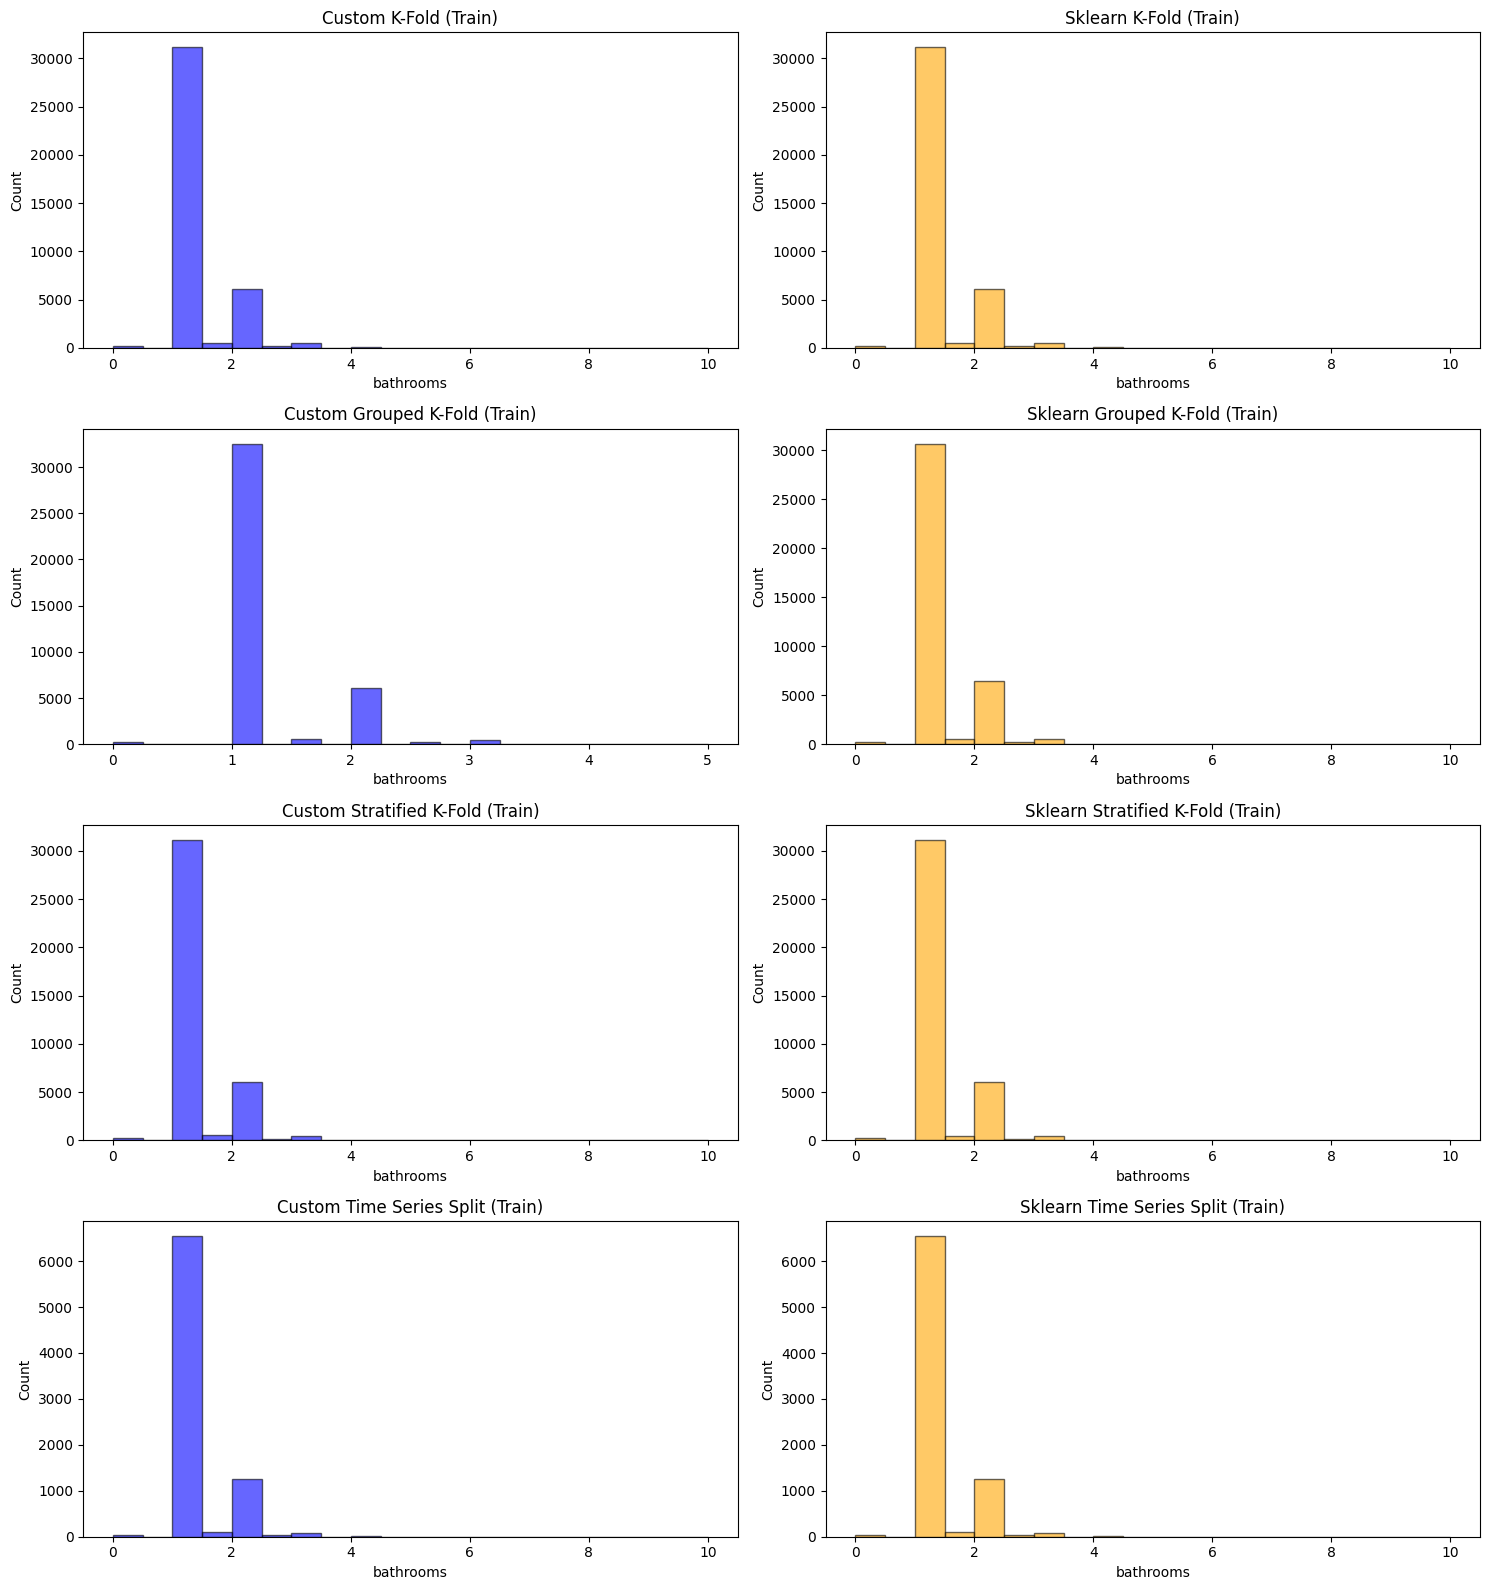

In [32]:
feature_to_plot = 'bathrooms'
fig, axes = plt.subplots(4, 2, figsize=(15, 16)) 

axes[0, 0].hist(my_kf[0][0][feature_to_plot], bins=20, color='blue', alpha=0.6, edgecolor='black')
axes[0, 0].set_title(f'Custom K-Fold (Train)')

axes[0, 1].hist(X_val.iloc[skf_kf[0][0]][feature_to_plot], bins=20, color='orange', alpha=0.6, edgecolor='black')
axes[0, 1].set_title(f'Sklearn K-Fold (Train)')

axes[1, 0].hist(my_gkf[0][0][feature_to_plot], bins=20, color='blue', alpha=0.6, edgecolor='black')
axes[1, 0].set_title(f'Custom Grouped K-Fold (Train)')

axes[1, 1].hist(X_val.iloc[skf_gkf[0][0]][feature_to_plot], bins=20, color='orange', alpha=0.6, edgecolor='black')
axes[1, 1].set_title(f'Sklearn Grouped K-Fold (Train)')

axes[2, 0].hist(X_val.loc[my_skf[0][0], feature_to_plot], bins=20, color='blue', alpha=0.6, edgecolor='black')
axes[2, 0].set_title(f'Custom Stratified K-Fold (Train)')

axes[2, 1].hist(X_val.iloc[skf_skf[0][0]][feature_to_plot], bins=20, color='orange', alpha=0.6, edgecolor='black')
axes[2, 1].set_title(f'Sklearn Stratified K-Fold (Train)')

axes[3, 0].hist(X_val.loc[my_tss[0][0], feature_to_plot], bins=20, color='blue', alpha=0.6, edgecolor='black')
axes[3, 0].set_title(f'Custom Time Series Split (Train)')

axes[3, 1].hist(X_val.sort_values('created').iloc[skf_tss[0][0]][feature_to_plot], bins=20, color='orange', alpha=0.6, edgecolor='black')
axes[3, 1].set_title(f'Sklearn Time Series Split (Train)')

for ax in axes.flat:
    ax.set_ylabel('Count')
    ax.set_xlabel(feature_to_plot)

plt.tight_layout()
plt.show()

In [33]:
from sklearn.metrics import mean_squared_error, r2_score


def evaluate_cv(model, X, y, cv, groups=None, stratify=None):

    rmse_scores = []
    r2_scores = []

    if stratify is not None:
        splits = cv.split(X, stratify)

    elif groups is not None:
        splits = cv.split(X, y, groups)

    else:
        splits = cv.split(X, y)

    for train_idx, test_idx in splits:

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        model.fit(X_train, y_train)

        pred = model.predict(X_test)

        rmse_scores.append(
            np.sqrt(mean_squared_error(y_test, pred))
        )

        r2_scores.append(
            r2_score(y_test, pred)
        )

    return {
        'RMSE_mean': np.mean(rmse_scores),
        'RMSE_std': np.std(rmse_scores),
        'R2_mean': np.mean(r2_scores),
        'R2_std': np.std(r2_scores),
        'n_splits': len(rmse_scores)
    }

In [34]:
model = Lasso(alpha=0.1)
results = []

y_binned = pd.qcut(y, q=5, labels=False, duplicates='drop')

results.append({
    'method': 'KFold',
    **evaluate_cv(model, X, y,
        KFold(n_splits=5, shuffle=True, random_state=42))
})

results.append({
    'method': 'StratifiedKFold',
    **evaluate_cv(model, X, y,                   
        StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        stratify=y_binned)
})

results.append({
    'method': 'GroupKFold',
    **evaluate_cv(model, X, y,
        GroupKFold(n_splits=5),
        groups=df['building_id'])
})

results.append({
    'method': 'TimeSeriesSplit',
    **evaluate_cv(model, X, y,
        TimeSeriesSplit(n_splits=5))
})

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=['RMSE_mean', 'R2_mean'],
    ascending=[True, False]
)

print(results_df)

            method    RMSE_mean   RMSE_std   R2_mean    R2_std  n_splits
3  TimeSeriesSplit  1003.070283  28.139584  0.606249  0.025306         5
1  StratifiedKFold  1004.858536  16.218087  0.604184  0.010928         5
0            KFold  1005.157872   8.002969  0.603972  0.010069         5
2       GroupKFold  1010.522327  33.100752  0.593501  0.047010         5


коэффициент асимметрии

In [35]:
y.skew()

np.float64(2.030582728418636)

- Несмотря на то, что GroupKFold показал чуть более высокие результаты, модель не использует характеристики, относящиеся к конкретным группам, такие как building_id. Поскольку целевая функция сильно асимметрична, StratifiedKFold обеспечивает более подходящую стратегию проверки, сохраняя распределение дорогих и недорогих квартир по слотам.

## **6. Feature Selection**

- Fit a Lasso regression model with normalized features. Use your method for splitting samples into 3 parts by field created with 60/20/20 ratio — train/validation/test.
- Sort features by weight coefficients from model, fit model to top 10 features and compare quality.
- Implement method for simple feature selection by nan-ratio in feature and correlation. Apply this method to feature set and take top 10 features, refit model and measure quality.
- Implement permutation importance method and take top 10 features, refit model and measure quality.
- Import Shap and also refit model on top 10 features.
- Compare the quality of these methods for different aspects — speed, metrics and stability.

In [36]:
X_train, X_val, X_test, y_train, y_val, y_test = random_split_val(X, y, test_size=0.2, validation_size=0.2, seed=42)

In [ ]:
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val),   columns=X_val.columns,   index=X_val.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),  columns=X_test.columns,  index=X_test.index)

timings = {}
metric_tables = {'MAE': [], 'RMSE': [], 'R2': []}


def evaluate(name, features=None):
    """Fit a Lasso model (on MinMax-scaled data) on the given feature subset and
    append one row per metric (MAE / RMSE / R2) with train / valid / test columns."""
    cols = list(features) if features is not None else list(X_train_scaled.columns)
    model = Lasso(random_state=21).fit(X_train_scaled[cols], y_train)
    parts = {
        'train': (X_train_scaled, y_train),
        'valid': (X_val_scaled,   y_val),
        'test':  (X_test_scaled,  y_test),
    }
    for metric_name, fn in [('MAE', mae), ('RMSE', rmse), ('R2', r2)]:
        row = {'model': name}
        for part, (X_part, y_part) in parts.items():
            row[part] = fn(y_part, model.predict(X_part[cols]))
        metric_tables[metric_name].append(row)
    return model


start = time.perf_counter()
lasso_full = evaluate('Lasso MinMaxScaler')
timings['Lasso MinMaxScaler'] = time.perf_counter() - start
print('Fitted Lasso on', X_train_scaled.shape[1], 'features,', X_train_scaled.shape[0], 'train rows')

Fitted Lasso on 24 features, 29029 train rows


In [ ]:
importance = pd.DataFrame(
    {'Name': X_train_scaled.columns, 'Importance': np.abs(lasso_full.coef_)}
).sort_values('Importance', ascending=False)
importance.index.name = 'ID'

top10_weight = importance.head(10)['Name'].tolist()
print('Top-10 by Lasso weight:', top10_weight)

start = time.perf_counter()
evaluate('Lasso top10 MinMaxScaler', top10_weight)
timings['Lasso top10 MinMaxScaler'] = time.perf_counter() - start

importance

Top-10 by Lasso weight: ['bathrooms', 'bedrooms', 'interest_level', 'Doorman', 'LaundryinUnit', 'Elevator', 'HighSpeedInternet', 'LaundryInBuilding', 'FitnessCenter', 'LaundryinBuilding']


,Name,Importance
ID,,
0,bathrooms,14634.253853
1,bedrooms,3375.261742
2,interest_level,848.085438
7,Doorman,564.710647
13,LaundryinUnit,449.489095
3,Elevator,208.075772
17,HighSpeedInternet,197.935777
20,LaundryInBuilding,187.357190
11,FitnessCenter,181.708150


In [ ]:
start = time.perf_counter()

nan_ratio = X_train.isna().mean()
kept = nan_ratio[nan_ratio < 0.5].index.tolist()

corr_matrix = X_train[kept].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
kept = [f for f in kept if f not in to_drop]

target_corr = X_train[kept].corrwith(y_train).abs().sort_values(ascending=False)
top10_nan_corr = target_corr.head(10).index.tolist()

evaluate('Lasso nan/corr MinMaxScaler', top10_nan_corr)
timings['Lasso nan/corr MinMaxScaler'] = time.perf_counter() - start

print('Top-10 by nan/corr:', top10_nan_corr)
target_corr.head(10).rename('abs_corr_with_target').to_frame()

Top-10 by nan/corr: ['bathrooms', 'bedrooms', 'Doorman', 'LaundryinUnit', 'FitnessCenter', 'DiningRoom', 'Dishwasher', 'Elevator', 'interest_level', 'OutdoorSpace']


,abs_corr_with_target
bathrooms,0.675217
bedrooms,0.548509
Doorman,0.280376
LaundryinUnit,0.263128
FitnessCenter,0.227533
DiningRoom,0.225650
Dishwasher,0.225605
Elevator,0.215297
interest_level,0.198567
OutdoorSpace,0.151011


In [ ]:
start = time.perf_counter()
perm = permutation_importance(
    lasso_full, X_val_scaled, y_val,
    n_repeats=10, random_state=42,
    scoring='neg_mean_absolute_percentage_error',
)
perm_importance = pd.DataFrame({
    'Feature': X_val_scaled.columns,
    'mean': np.abs(perm.importances_mean),
    'std':  perm.importances_std,
}).sort_values('mean', ascending=False).reset_index(drop=True)
perm_importance['Mean ± Std Deviation'] = perm_importance.apply(
    lambda r: f"{r['mean']:.5f} ± {r['std']:.3f}", axis=1
)
top10_perm = perm_importance.head(10)['Feature'].tolist()

evaluate('Lasso permutation MinMaxScaler', top10_perm)
timings['Lasso permutation MinMaxScaler'] = time.perf_counter() - start

perm_importance[['Feature', 'Mean ± Std Deviation']].head(10)

,Feature,Mean ± Std Deviation
0,bedrooms,0.07672 ± 0.001
1,bathrooms,0.07153 ± 0.001
2,Doorman,0.02877 ± 0.001
3,interest_level,0.02180 ± 0.000
4,LaundryinUnit,0.00806 ± 0.000
5,Elevator,0.00432 ± 0.000
6,FitnessCenter,0.00300 ± 0.000
7,Dishwasher,0.00263 ± 0.000
8,LaundryinBuilding,0.00157 ± 0.000
9,HighSpeedInternet,0.00079 ± 0.000


In [ ]:
start = time.perf_counter()
explainer = shap.LinearExplainer(lasso_full, X_train_scaled)
shap_values = explainer.shap_values(X_val_scaled)
shap_importance = pd.DataFrame({
    'feature': X_val_scaled.columns,
    'shap_value': np.abs(shap_values).mean(axis=0),
}).sort_values('shap_value', ascending=False)
shap_importance.index.name = 'id'
top10_shap = shap_importance.head(10)['feature'].tolist()

evaluate('Lasso shap MinMaxScaler', top10_shap)
timings['Lasso shap MinMaxScaler'] = time.perf_counter() - start

shap_importance.head(10)

Background dataset has 29029 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=29029 when initializing the masker.


,feature,shap_value
id,,
1,bedrooms,444.633483
0,bathrooms,420.018968
7,Doorman,273.886707
2,interest_level,218.462426
13,LaundryinUnit,130.949763
3,Elevator,103.783679
10,LaundryinBuilding,82.015414
8,Dishwasher,71.425015
11,FitnessCenter,70.047130


In [ ]:
from IPython.display import display

mae_table  = pd.DataFrame(metric_tables['MAE'])
rmse_table = pd.DataFrame(metric_tables['RMSE'])
r2_table   = pd.DataFrame(metric_tables['R2'])

print('MAE');  display(mae_table)
print('RMSE'); display(rmse_table)
print('R²'); display(r2_table)

speed = pd.DataFrame(
    {'method': list(timings.keys()), 'seconds': list(timings.values())}
).sort_values('seconds').reset_index(drop=True)
print('Speed (seconds)'); display(speed)

MAE


,model,train,valid,test
0,Lasso MinMaxScaler,690.197872,683.760836,694.616776
1,Lasso top10 MinMaxScaler,693.794245,685.599860,697.890168
2,Lasso nan/corr MinMaxScaler,699.794484,692.212599,703.851250
3,Lasso permutation MinMaxScaler,693.189201,685.697072,697.178557
4,Lasso shap MinMaxScaler,694.095309,686.801215,697.670209


RMSE


,model,train,valid,test
0,Lasso MinMaxScaler,1002.250721,998.957720,1018.208002
1,Lasso top10 MinMaxScaler,1007.597346,1002.924391,1023.679501
2,Lasso nan/corr MinMaxScaler,1014.122579,1011.321551,1030.084687
3,Lasso permutation MinMaxScaler,1007.798691,1003.455182,1023.719313
4,Lasso shap MinMaxScaler,1008.700834,1004.366729,1024.095456


R²


,model,train,valid,test
0,Lasso MinMaxScaler,0.607899,0.608519,0.589774
1,Lasso top10 MinMaxScaler,0.603705,0.605403,0.585353
2,Lasso nan/corr MinMaxScaler,0.598555,0.598768,0.580148
3,Lasso permutation MinMaxScaler,0.603546,0.604986,0.585321
4,Lasso shap MinMaxScaler,0.602836,0.604268,0.585016


Speed (seconds)


,method,seconds
0,Lasso shap MinMaxScaler,0.101149
1,Lasso top10 MinMaxScaler,0.134499
2,Lasso nan/corr MinMaxScaler,0.217777
3,Lasso MinMaxScaler,0.355982
4,Lasso permutation MinMaxScaler,2.332851


## **7. Hyperparameter optimization**

- Implement grid search and random search methods for alpha and l1_ratio for sklearn's ElasticNet model.
- Find the best combination of model hyperparameters.
- Fit the resulting model.
- Import optuna and configure the same experiment with ElasticNet.
- Estimate metrics and compare approaches.
- Run optuna on one of the cross-validation schemes.

In [43]:
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7]
}

scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

grid_search = GridSearchCV(
    estimator=ElasticNet(random_state=42, max_iter=10000),         
    param_grid=param_grid,      
    scoring='neg_mean_squared_error',  
    cv=5,                       
    n_jobs=-1,                   
    verbose=1,                   
    return_train_score=True      
)

grid_search.fit(X_train_scaled, y_train)

print('Best params:', grid_search.best_params_)
print('Best CV score:', grid_search.best_score_)

best_elastic_grid = grid_search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'alpha': 0.001, 'l1_ratio': 0.7}
Best CV score: -1015829.0491622433


In [44]:
y_train_pred_grid = best_elastic_grid.predict(X_train_scaled)
y_val_pred_grid = best_elastic_grid.predict(X_val_scaled)
y_test_pred_grid = best_elastic_grid.predict(X_test_scaled)

result_score_grid = pd.DataFrame({
    'model': ['elastic_grid'],
    'mae_train': [mae(y_train, y_train_pred_grid)],
    'mae_valid': [mae(y_val, y_val_pred_grid)],
    'mae_test': [mae(y_test, y_test_pred_grid)],
    'rmse_train': [rmse(y_train, y_train_pred_grid)],
    'rmse_valid': [rmse(y_val, y_val_pred_grid)],
    'rmse_test': [rmse(y_test, y_test_pred_grid)],
    'r2_train': [r2(y_train, y_train_pred_grid)],
    'r2_valid': [r2(y_val, y_val_pred_grid)],
    'r2_test': [r2(y_test, y_test_pred_grid)]
})

result_score_grid

,model,mae_train,mae_valid,mae_test,rmse_train,rmse_valid,rmse_test,r2_train,r2_valid,r2_test
0,elastic_grid,694.455746,687.445335,697.951854,1006.430485,1003.170541,1021.769773,0.604622,0.60521,0.586899


In [45]:
param_dist = {
    'alpha': uniform(0.001, 10.0),
    'l1_ratio': uniform(0.0, 1.0)
}

random_search = RandomizedSearchCV(
    estimator=ElasticNet(random_state=42, max_iter=10000),
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    return_train_score=True
)

random_search.fit(X_train_scaled, y_train)

print('Best params:', random_search.best_params_)
print('Best CV score:', random_search.best_score_)

best_elastic_random = random_search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'alpha': np.float64(0.20684494295802447), 'l1_ratio': np.float64(0.9699098521619943)}
Best CV score: -1234413.3482834292


In [46]:
y_train_pred_random = best_elastic_random.predict(X_train_scaled)
y_val_pred_random = best_elastic_random.predict(X_val_scaled)
y_test_pred_random = best_elastic_random.predict(X_test_scaled)

result_score_random = pd.DataFrame({
    'model': ['elastic_random'],
    'mae_train': [mae(y_train, y_train_pred_random)],
    'mae_valid': [mae(y_val, y_val_pred_random)],
    'mae_test': [mae(y_test, y_test_pred_random)],
    'rmse_train': [rmse(y_train, y_train_pred_random)],
    'rmse_valid': [rmse(y_val, y_val_pred_random)],
    'rmse_test': [rmse(y_test, y_test_pred_random)],
    'r2_train': [r2(y_train, y_train_pred_random)],
    'r2_valid': [r2(y_val, y_val_pred_random)],
    'r2_test': [r2(y_test, y_test_pred_random)]
})

result_score_random

,model,mae_train,mae_valid,mae_test,rmse_train,rmse_valid,rmse_test,r2_train,r2_valid,r2_test
0,elastic_random,756.006789,744.585885,753.459118,1109.843011,1103.766082,1116.577435,0.519196,0.522063,0.506681


In [47]:
from sklearn.model_selection import cross_val_score

def objective(trial):
    alpha = trial.suggest_float('alpha', 0.001, 10.0, log=True)
    l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)

    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42, max_iter=10000)

    score = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1).mean()

    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

print('Best params:', study.best_params)
print('Best CV score:', study.best_value)

best_elastic_optuna = ElasticNet(alpha=study.best_params['alpha'], l1_ratio=study.best_params['l1_ratio'], random_state=42, max_iter=10000)
best_elastic_optuna.fit(X_train_scaled, y_train)

y_train_pred_optuna = best_elastic_optuna.predict(X_train_scaled)
y_val_pred_optuna = best_elastic_optuna.predict(X_val_scaled)
y_test_pred_optuna = best_elastic_optuna.predict(X_test_scaled)

result_score_optuna = pd.DataFrame({
    'model': ['elastic_optuna'],
    'mae_train': [mae(y_train, y_train_pred_optuna)],
    'mae_valid': [mae(y_val, y_val_pred_optuna)],
    'mae_test': [mae(y_test, y_test_pred_optuna)],
    'rmse_train': [rmse(y_train, y_train_pred_optuna)],
    'rmse_valid': [rmse(y_val, y_val_pred_optuna)],
    'rmse_test': [rmse(y_test, y_test_pred_optuna)],
    'r2_train': [r2(y_train, y_train_pred_optuna)],
    'r2_valid': [r2(y_val, y_val_pred_optuna)],
    'r2_test': [r2(y_test, y_test_pred_optuna)],
    'best_params': [study.best_params]
})

result_score_optuna

[I 2026-07-10 16:42:06,631] A new study created in memory with name: no-name-cb0dd563-7f24-473e-9b2f-fcc96170cdf2
[I 2026-07-10 16:42:07,155] Trial 0 finished with value: -2397369.1117211385 and parameters: {'alpha': 6.640248000152088, 'l1_ratio': 0.6960775584490025}. Best is trial 0 with value: -2397369.1117211385.
[I 2026-07-10 16:42:07,998] Trial 1 finished with value: -1337559.6985197135 and parameters: {'alpha': 0.018695508582971185, 'l1_ratio': 0.31491466543760416}. Best is trial 1 with value: -1337559.6985197135.
[I 2026-07-10 16:42:09,548] Trial 2 finished with value: -1042104.5551985956 and parameters: {'alpha': 0.0011211736599184394, 'l1_ratio': 0.3408716073732474}. Best is trial 2 with value: -1042104.5551985956.
[I 2026-07-10 16:42:10,530] Trial 3 finished with value: -1333520.9841304382 and parameters: {'alpha': 0.01642275098367861, 'l1_ratio': 0.23836670039708108}. Best is trial 2 with value: -1042104.5551985956.
[I 2026-07-10 16:42:10,851] Trial 4 finished with value: -1

Best params: {'alpha': 0.0033694603586030356, 'l1_ratio': 0.9970757322730118}
Best CV score: -1006813.4999011751


,model,mae_train,mae_valid,mae_test,rmse_train,rmse_valid,rmse_test,r2_train,r2_valid,r2_test,best_params
0,elastic_optuna,690.608219,684.601423,694.983922,1001.808975,998.829075,1017.8495,0.608245,0.608619,0.590063,"{'alpha': 0.0033694603586030356, 'l1_ratio': 0..."


In [48]:
result_score_all = pd.concat([
    result_score_grid,
    result_score_random,
    result_score_optuna
], ignore_index=True)

result_score_all

,model,mae_train,mae_valid,mae_test,rmse_train,rmse_valid,rmse_test,r2_train,r2_valid,r2_test,best_params
0,elastic_grid,694.455746,687.445335,697.951854,1006.430485,1003.170541,1021.769773,0.604622,0.605210,0.586899,NaN
1,elastic_random,756.006789,744.585885,753.459118,1109.843011,1103.766082,1116.577435,0.519196,0.522063,0.506681,NaN
2,elastic_optuna,690.608219,684.601423,694.983922,1001.808975,998.829075,1017.849500,0.608245,0.608619,0.590063,"{'alpha': 0.0033694603586030356, 'l1_ratio': 0..."


In [49]:
pd.DataFrame({
    "method": ["grid", "random", "optuna"],
    "iterations": [len(list(grid_search.cv_results_["params"])), random_search.n_iter, len(study.trials)],
    "best_cv_score": [grid_search.best_score_, random_search.best_score_, study.best_value]
})

,method,iterations,best_cv_score
0,grid,20,-1.015829e+06
1,random,20,-1.234413e+06
2,optuna,20,-1.006813e+06
